In [ ]:
#import Labraries
import pandas as pd
import matplotlib.pyplot as plt
import ast

# import data 
df = pd.read_csv (r'C:\Users\PC\Documents\Learning_PYTHON\data_jobs.csv')
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply( lambda x: ast.literal_eval(x) if pd.notna(x) else x)


# You mession : You already know how to use the 'Explode' Fonction , 
# Your mession here is make a chart represent the demand of the skills by job types . Speacily the data analyst skills

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [ ]:
# Explode the job skills column
df_exploded = df.explode('job_skills')   # Note : all data in df is here , just the column is exploded

In [9]:
# Group the job skills column by job short title 
skills_count = df_exploded.groupby ([ 'job_title_short' , 'job_skills']).size()     # Note : this is a series . its better to be dataFrame

In [15]:
# Tranforme the series into DF using 'reser_index'
df_skills_count = skills_count.reset_index(name="skills_count").sort_values(by='skills_count' , ascending=False)

df_skills_count

,job_title_short,job_skills,skills_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


In [ ]:
# Now let's make a chart for data analyst's top skills only 
job_title = 'Data Analyst'    # We make it in a variable just uncase if we want to see other job title 
top_skills = 10

df_skills_Final = df_skills_count[df_skills_count['job_title_short']==job_title].head(top_skills)
df_skills_Final

,job_title_short,job_skills,skills_count
625,Data Analyst,sql,92428
494,Data Analyst,excel,66860
590,Data Analyst,python,57190
638,Data Analyst,tableau,46455
583,Data Analyst,power bi,39380
594,Data Analyst,r,29996
606,Data Analyst,sas,27998
585,Data Analyst,powerpoint,13822
664,Data Analyst,word,13562
605,Data Analyst,sap,11280


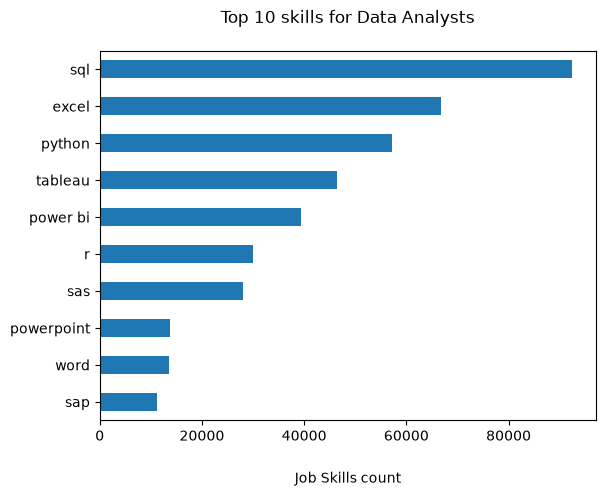

In [39]:
df_skills_Final.plot(kind='barh' , x='job_skills' , y='skills_count')
plt.gca().invert_yaxis()   # To rescending the values in the Y label 
plt.title(f'Top {top_skills} skills for {job_title}s' , pad=20)
plt.ylabel('')
plt.xlabel ('Job Skills count', labelpad=20)
plt.legend().set_visible(False)    # to make the legend visible or not 
plt.show()